In [1]:
import pandas as pd

file_path = r"/data/subset/01-12/flow-level/combined_subset_12k.parquet"
df = pd.read_parquet(file_path)

In [2]:
print(f"Initial shape: {df.shape}")

Initial shape: (144000, 88)


In [3]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


In [4]:
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Shape after removing duplicates: (144000, 88)


In [5]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
Flow Bytes/s    2477
dtype: int64


In [6]:
# Check data types
print("\nData types:")
print(df.dtypes)


Data types:
Unnamed: 0          int64
Flow ID            object
Source IP          object
Source Port         int64
Destination IP     object
                   ...   
Idle Max          float64
Idle Min          float64
SimillarHTTP       object
Inbound             int64
Label              object
Length: 88, dtype: object


In [7]:
# Impute "Flow Bytes/s" with median
df['Flow Bytes/s'] = df['Flow Bytes/s'].fillna(df['Flow Bytes/s'].median())

In [8]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
Series([], dtype: int64)


In [9]:
# Group and list all column names by data type
column_types = df.dtypes.value_counts()
print("Column types count:\n", column_types)

print("\nColumns grouped by data type:")
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())

Column types count:
 float64    45
int64      37
object      6
Name: count, dtype: int64

Columns grouped by data type:

int64 columns:
['Unnamed: 0', 'Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Inbound']

object columns:
['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP', 'Label']

float64 columns:
['Total Length 

In [10]:
# Drop unneeded object columns
df.drop(columns=['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP'], inplace=True)

In [11]:
# Encode the Label column
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['Label'] = label_encoder.fit_transform(df['Label'])

In [12]:
# Split features and target
X = df.drop(columns=['Label'])
y = df['Label']

In [13]:
# Group and list all column names by data type
column_types = df.dtypes.value_counts()
print("Column types count:\n", column_types)

print("\nColumns grouped by data type:")
for dtype in df.dtypes.unique():
    print(f"\n{dtype} columns:")
    print(df.select_dtypes(include=[dtype]).columns.tolist())

Column types count:
 float64    45
int64      38
Name: count, dtype: int64

Columns grouped by data type:

int64 columns:
['Unnamed: 0', 'Source Port', 'Destination Port', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Fwd Header Length.1', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Inbound', 'Label']

float64 columns:
['Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd 

In [14]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [15]:
# Train_Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [16]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (115200, 82)
X_test shape: (28800, 82)
y_train shape: (115200,)
y_test shape: (28800,)


In [17]:
# Label distribution in train and test sets
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Label
3     0.083333
6     0.083333
7     0.083333
4     0.083333
8     0.083333
5     0.083333
1     0.083333
9     0.083333
11    0.083333
2     0.083333
0     0.083333
10    0.083333
Name: proportion, dtype: float64
Label
3     0.083333
4     0.083333
10    0.083333
6     0.083333
8     0.083333
0     0.083333
2     0.083333
9     0.083333
5     0.083333
11    0.083333
7     0.083333
1     0.083333
Name: proportion, dtype: float64


In [18]:
import numpy as np

print(df['Label'].dtype)
print(df['Label'].unique())
are_all_integers = all(isinstance(x, (int, np.integer)) for x in df['Label'])
print("All labels are integers (encoded):", are_all_integers)

int64
[ 0  1  2  3  5  4  6  7  8  9 10 11]
All labels are integers (encoded): True


In [19]:
# For X_train
print("Checking inf values in X_train:")
print(np.isinf(X_train).sum())

# Replace inf with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)

# Impute NaN with median
X_train.fillna(X_train.median(), inplace=True)

# For X_test
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.fillna(X_test.median(), inplace=True)

Checking inf values in X_train:
Unnamed: 0          0
Source Port         0
Destination Port    0
Protocol            0
Flow Duration       0
                   ..
Idle Mean           0
Idle Std            0
Idle Max            0
Idle Min            0
Inbound             0
Length: 82, dtype: int64


## XGBOOST Feature Importance

In [20]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

In [21]:
# Prepare data
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_test.shape}")
print(f"y_val shape: {y_test.shape}")

X_train shape: (115200, 82)
y_train shape: (115200,)
X_val shape: (28800, 82)
y_val shape: (28800,)


In [22]:
# XGBoost model and hyperparameter search space
xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=12,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    use_label_encoder=False,
    verbosity=1,
)

param_dist = {
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500, 800],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 1.5, 2, 3],
}

print("Model and hyperparameter space defined.")

Model and hyperparameter space defined.


In [ ]:
# Setup RandomizedSearchCV with early stopping
# Wrapper to enable early stopping during CV
# def fit_with_early_stopping(estimator, X, y):
#     # Split train into train/valid internally for early stopping
#     X_train_inner, X_val_inner, y_train_inner, y_val_inner = train_test_split(
#         X, y, test_size=0.2, stratify=y, random_state=42
#     )
#     estimator.fit(
#         X_train_inner, y_train_inner,
#         eval_set=[(X_val_inner, y_val_inner)],
#         early_stopping_rounds=10,
#         verbose=False
#     )
#     return estimator

from sklearn.base import clone

# class XGBEarlyStoppingWrapper(xgb.XGBClassifier):
#     def fit(self, X, y, **kwargs):
#         # use internal validation split for early stopping
#         return fit_with_early_stopping(super(), X, y)
#
# xgb_es_model = XGBEarlyStoppingWrapper(
#     objective='multi:softmax',
#     num_class=12,
#     tree_method='hist',
#     device='cuda',
#     eval_metric='mlogloss',
#     use_label_encoder=False,
#     verbosity=0,
# )

random_search = RandomizedSearchCV(
    # estimator=xgb_es_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1,
)

print("RandomizedSearchCV with early stopping set up.")

In [29]:
# Run hyperparameter search
random_search.fit(X_train, y_train)

print(f"Best params: {random_search.best_params_}")
print(f"Best cross-val accuracy: {random_search.best_score_:.4f}")

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=8, n_estimators=300, reg_alpha=0, reg_lambda=1.5, subsample=0.6; total time=  19.6s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=8, n_estimators=300, reg_alpha=0, reg_lambda=1.5, subsample=0.6; total time=  22.0s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.01, max_depth=8, n_estimators=300, reg_alpha=0, reg_lambda=1.5, subsample=0.6; total time=  21.0s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=  11.2s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=  11.8s
[CV] END colsample_bytree=0.6, gamma=0, learning_rate=0.05, max_depth=4, n_estimators=300, reg_alpha=1, reg_lambda=2, subsample=1.0; total time=  11.8s
[CV] END colsam

In [44]:
print(random_search.best_params_)

# save best params to a json file
import json
with open("best_xgb_params.json", "w") as f:
    json.dump(random_search.best_params_, f)

{'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [24]:
# Load best params from json file
import json

with open("best_xgb_params.json", "r") as f:
    best_params = json.load(f)

print("Best parameters loaded from file:", best_params)

Best parameters loaded from file: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 1, 'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}


In [25]:
import importlib
import xgboost
importlib.reload(xgboost)

<module 'xgboost' from 'C:\\Users\\AGFirass\\Documents\\GitHub\\Transformer-Based-DDoS-Detection\\venv\\lib\\site-packages\\xgboost\\__init__.py'>

In [ ]:
# Train final model on full train set with best params and early stopping on validation
# best_params = random_search.best_params_

import xgboost as xgb

final_model = xgb.XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=12,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    use_label_encoder=False,
    verbosity=1,
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    early_stopping_rounds=10,
    verbose=True
)


# final_model = xgb.XGBClassifier(
#     **best_params,
#     objective='multi:softmax',
#     num_class=12,
#     tree_method='hist',
#     device='cuda',
#     eval_metric='mlogloss',
#     use_label_encoder=False,
#     verbosity=1,
# )
#
# from xgboost import callback
#
# # Ensure early stopping is active
# final_model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     early_stopping_rounds=10,  # RE-ENABLE THIS!
#     # callbacks=[callback.EarlyStopping(rounds=10)],
#     verbose=True
# )

# Check if early stopping happened
best_iteration = final_model.best_iteration
# if best_iteration is not None:
#     val_preds = final_model.predict(X_test, iteration_range=(0, best_iteration + 1))
# else:
#     val_preds = final_model.predict(X_test)
if getattr(final_model, "best_iteration", None) is not None:
    val_preds = final_model.predict(X_test, iteration_range=(0, final_model.best_iteration + 1))
else:
    val_preds = final_model.predict(X_test)


val_acc = accuracy_score(y_test, val_preds)
print(f"Validation Accuracy of final model: {val_acc:.4f}")

In [ ]:
# Feature importance extraction and display
importance = final_model.get_booster().get_score(importance_type='gain')
importance = dict(sorted(importance.items(), key=lambda item: item[1], reverse=True))

print("Top features by gain:")
for feat, score in importance.items():
    print(f"{feat}: {score:.4f}")

In [ ]:
xgb.plot_importance(final_model, importance_type='gain', max_num_features=20)

# NEW XGBOOST

In [27]:
import pandas as pd
import xgboost as xgb
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [28]:
# Load best parameters from JSON file
with open("best_xgb_params.json", "r") as f:
    best_params = json.load(f)

print("Best parameters loaded:")
for key, value in best_params.items():
    print(f"  {key}: {value}")

Best parameters loaded:
  subsample: 1.0
  reg_lambda: 1.5
  reg_alpha: 1
  n_estimators: 800
  max_depth: 8
  learning_rate: 0.05
  gamma: 0.3
  colsample_bytree: 0.8


In [29]:
# Create and train the final XGBoost model
print("Training XGBoost model with best parameters...")

final_model = xgb.XGBClassifier(
    **best_params,
    objective='multi:softmax',
    num_class=12,
    tree_method='hist',
    device='cuda',
    eval_metric='mlogloss',
    random_state=42,
    verbosity=1
)

# Fit the model
final_model.fit(X_train, y_train)
print("Model training completed!")

Training XGBoost model with best parameters...
Model training completed!


In [31]:
# Make predictions and evaluate
y_pred = final_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Number of features: {X_train.shape[1]}")

Model Performance:
Test Accuracy: 0.9336
Training samples: 115200
Test samples: 28800
Number of features: 82


In [32]:
# Method 1: Using feature_importances_ property
print("Feature Importance Analysis - Method 1 (Sklearn Style)")
print("="*60)

importance_gain = final_model.feature_importances_
feature_names = X_train.columns

importance_df_gain = pd.DataFrame({
    'feature': feature_names,
    'importance': importance_gain
}).sort_values('importance', ascending=False)

print("Top 20 Features by Gain:")
print(importance_df_gain.head(20))

Feature Importance Analysis - Method 1 (Sklearn Style)
Top 20 Features by Gain:
                    feature  importance
50           ACK Flag Count    0.320937
71         act_data_pkt_fwd    0.148958
56     Avg Fwd Segment Size    0.066706
81                  Inbound    0.052926
78                 Idle Std    0.042255
43       Packet Length Mean    0.037957
11   Fwd Packet Length Mean    0.036736
55      Average Packet Size    0.034882
41        Min Packet Length    0.033479
42        Max Packet Length    0.021345
51           URG Flag Count    0.019759
69   Init_Win_bytes_forward    0.017452
70  Init_Win_bytes_backward    0.014861
23            Fwd IAT Total    0.012810
72     min_seg_size_forward    0.010885
12    Fwd Packet Length Std    0.009556
66        Subflow Fwd Bytes    0.008912
10    Fwd Packet Length Min    0.008735
1               Source Port    0.007868
52           CWE Flag Count    0.007448


In [33]:
# Method 2: Using XGBoost native get_score method
print("Feature Importance Analysis - Method 2 (XGBoost Native)")
print("="*60)

try:
    importance_dict = final_model.get_booster().get_score(importance_type='gain')
    importance_sorted = dict(sorted(importance_dict.items(), key=lambda x: x[1], reverse=True))

    print("Top 20 Features:")
    for i, (feature, score) in enumerate(importance_sorted.items()):
        if i < 20:
            print(f"{feature}: {score:.4f}")
        else:
            break

except Exception as e:
    print(f"Error getting booster scores: {e}")

Feature Importance Analysis - Method 2 (XGBoost Native)
Top 20 Features:
ACK Flag Count: 2440.6724
act_data_pkt_fwd: 1132.8053
Avg Fwd Segment Size: 507.2880
Inbound: 402.4913
Idle Std: 321.3404
Packet Length Mean: 288.6598
Fwd Packet Length Mean: 279.3719
Average Packet Size: 265.2710
Min Packet Length: 254.6056
Max Packet Length: 162.3280
URG Flag Count: 150.2617
Init_Win_bytes_forward: 132.7181
Init_Win_bytes_backward: 113.0179
Fwd IAT Total: 97.4166
min_seg_size_forward: 82.7783
Fwd Packet Length Std: 72.6712
Subflow Fwd Bytes: 67.7711
Fwd Packet Length Min: 66.4256
Source Port: 59.8315
CWE Flag Count: 56.6426


In [34]:
# Method 3: Different importance types comparison
print("Different Importance Types Comparison")
print("="*40)

importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

for imp_type in importance_types:
    try:
        importance_dict = final_model.get_booster().get_score(importance_type=imp_type)
        if importance_dict:
            # Get top 3 features for each type
            sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)[:3]
            print(f"\n{imp_type.upper()}:")
            for feature, score in sorted_features:
                print(f"  {feature}: {score:.4f}")
    except Exception as e:
        print(f"Error with {imp_type}: {e}")

Different Importance Types Comparison

WEIGHT:
  Source Port: 15631.0000
  Unnamed: 0: 12694.0000
  Destination Port: 10648.0000

GAIN:
  ACK Flag Count: 2440.6724
  act_data_pkt_fwd: 1132.8053
  Avg Fwd Segment Size: 507.2880

COVER:
  ACK Flag Count: 6400.6265
  act_data_pkt_fwd: 3453.0391
  Fwd Packet Length Std: 2732.7817

TOTAL_GAIN:
  Source Port: 935226.9375
  Unnamed: 0: 680133.7500
  ACK Flag Count: 439321.0312

TOTAL_COVER:
  Source Port: 15122692.0000
  Unnamed: 0: 12941359.0000
  min_seg_size_forward: 4432454.0000


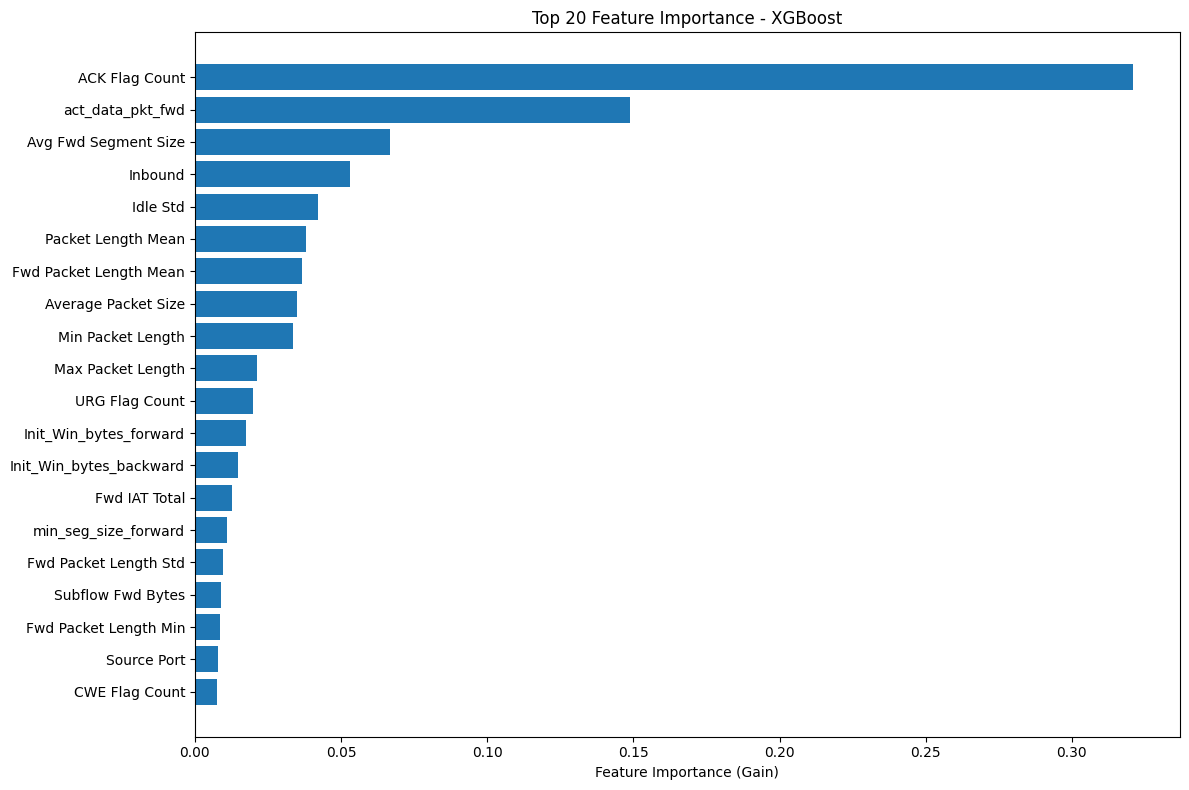

Bar plot created successfully!


In [35]:
# Create feature importance bar plot
plt.figure(figsize=(12, 8))

top_20_features = importance_df_gain.head(20)
plt.barh(range(len(top_20_features)), top_20_features['importance'])
plt.yticks(range(len(top_20_features)), top_20_features['feature'])
plt.xlabel('Feature Importance (Gain)')
plt.title('Top 20 Feature Importance - XGBoost')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Bar plot created successfully!")

<Figure size 1000x800 with 0 Axes>

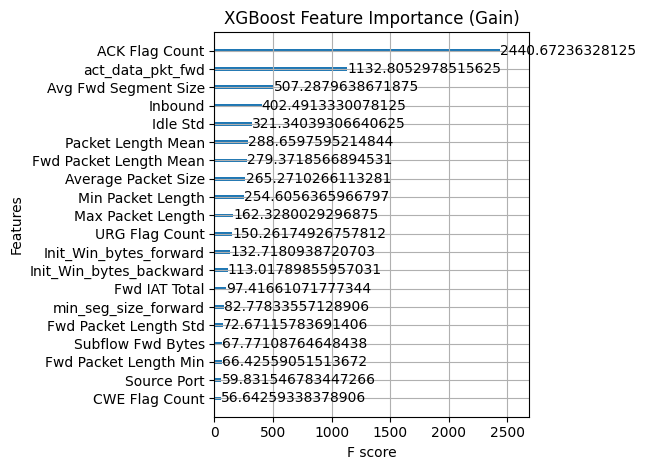

XGBoost native plot created successfully!


In [36]:
# XGBoost built-in importance plot
plt.figure(figsize=(10, 8))

try:
    xgb.plot_importance(final_model, importance_type='gain', max_num_features=20,
                       title='XGBoost Feature Importance (Gain)')
    plt.tight_layout()
    plt.show()
    print("XGBoost native plot created successfully!")
except Exception as e:
    print(f"Error creating XGBoost plot: {e}")

In [37]:
# Create comprehensive feature importance DataFrame
print("Creating Comprehensive Feature Importance Analysis...")

comprehensive_importance = pd.DataFrame({'feature': feature_names})

try:
    # Add different importance types
    for imp_type in ['weight', 'gain', 'cover']:
        importance_dict = final_model.get_booster().get_score(importance_type=imp_type)

        # Map XGBoost feature names (f0, f1, f2...) to actual feature names
        importance_values = []
        for feature in feature_names:
            feature_idx = list(feature_names).index(feature)
            xgb_feature_name = f'f{feature_idx}'
            importance_values.append(importance_dict.get(xgb_feature_name, 0.0))

        comprehensive_importance[f'importance_{imp_type}'] = importance_values

    # Add sklearn feature_importances_ (gain-based)
    comprehensive_importance['importance_sklearn'] = importance_gain

    # Sort by gain importance
    comprehensive_importance = comprehensive_importance.sort_values('importance_gain', ascending=False)

    print("Top 15 Features with All Metrics:")
    print(comprehensive_importance.head(15).round(4))

except Exception as e:
    print(f"Error creating comprehensive importance: {e}")
    # Fallback to simple importance
    comprehensive_importance = importance_df_gain.copy()

Creating Comprehensive Feature Importance Analysis...
Top 15 Features with All Metrics:
                        feature  importance_weight  importance_gain  \
0                    Unnamed: 0                0.0              0.0   
1                   Source Port                0.0              0.0   
2              Destination Port                0.0              0.0   
3                      Protocol                0.0              0.0   
4                 Flow Duration                0.0              0.0   
5             Total Fwd Packets                0.0              0.0   
6        Total Backward Packets                0.0              0.0   
7   Total Length of Fwd Packets                0.0              0.0   
8   Total Length of Bwd Packets                0.0              0.0   
9         Fwd Packet Length Max                0.0              0.0   
10        Fwd Packet Length Min                0.0              0.0   
11       Fwd Packet Length Mean                0.0          

In [38]:
# Save feature importance results
print("Saving Feature Importance Results...")

# Save simple importance
importance_df_gain.to_csv('xgboost_feature_importance_gain.csv', index=False)
print("✓ Simple feature importance saved to 'xgboost_feature_importance_gain.csv'")

# Save comprehensive importance if available
try:
    comprehensive_importance.to_csv('comprehensive_feature_importance.csv', index=False)
    print("✓ Comprehensive feature importance saved to 'comprehensive_feature_importance.csv'")
except:
    print("! Could not save comprehensive importance - using simple version")

# Display summary statistics
print(f"\nSummary:")
print(f"- Total features analyzed: {len(feature_names)}")
print(f"- Top feature: {importance_df_gain.iloc[0]['feature']}")
print(f"- Top feature importance: {importance_df_gain.iloc[0]['importance']:.4f}")
print(f"- Features with non-zero importance: {(importance_df_gain['importance'] > 0).sum()}")

Saving Feature Importance Results...
✓ Simple feature importance saved to 'xgboost_feature_importance_gain.csv'
✓ Comprehensive feature importance saved to 'comprehensive_feature_importance.csv'

Summary:
- Total features analyzed: 82
- Top feature: ACK Flag Count
- Top feature importance: 0.3209
- Features with non-zero importance: 70


In [39]:
# Generate a summary report
print("FEATURE IMPORTANCE SUMMARY REPORT")
print("="*50)

# Top 10 most important features
print("\nTOP 10 MOST IMPORTANT FEATURES:")
top_10 = importance_df_gain.head(10)
for i, row in top_10.iterrows():
    print(f"{row.name + 1:2d}. {row['feature']:30s} {row['importance']:.6f}")

# Feature importance distribution
print(f"\nFEATURE IMPORTANCE STATISTICS:")
print(f"Mean importance: {importance_df_gain['importance'].mean():.6f}")
print(f"Std importance:  {importance_df_gain['importance'].std():.6f}")
print(f"Max importance:  {importance_df_gain['importance'].max():.6f}")
print(f"Min importance:  {importance_df_gain['importance'].min():.6f}")

# Cumulative importance of top N features
cumulative_importance = importance_df_gain['importance'].cumsum()
total_importance = importance_df_gain['importance'].sum()

for n in [5, 10, 20, 30]:
    if n <= len(importance_df_gain):
        percentage = (cumulative_importance.iloc[n-1] / total_importance) * 100
        print(f"Top {n:2d} features account for {percentage:.1f}% of total importance")

print("\nAnalysis completed successfully! 🎉")

FEATURE IMPORTANCE SUMMARY REPORT

TOP 10 MOST IMPORTANT FEATURES:
51. ACK Flag Count                 0.320937
72. act_data_pkt_fwd               0.148958
57. Avg Fwd Segment Size           0.066706
82. Inbound                        0.052926
79. Idle Std                       0.042255
44. Packet Length Mean             0.037957
12. Fwd Packet Length Mean         0.036736
56. Average Packet Size            0.034882
42. Min Packet Length              0.033479
43. Max Packet Length              0.021345

FEATURE IMPORTANCE STATISTICS:
Mean importance: 0.012195
Std importance:  0.039981
Max importance:  0.320937
Min importance:  0.000000
Top  5 features account for 63.2% of total importance
Top 10 features account for 79.6% of total importance
Top 20 features account for 91.4% of total importance
Top 30 features account for 96.2% of total importance

Analysis completed successfully! 🎉
